In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("netflix_cleaned.csv")

In [6]:
df.shape

(8807, 17)

In [7]:
genre_df=pd.read_csv("netflix_genres.csv")

In [8]:
genre_df.shape

(19323, 2)

# EDA 1 — Movies vs TV Shows

## Objective
Analyze the distribution of Movies and TV Shows available on Netflix.

In [10]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

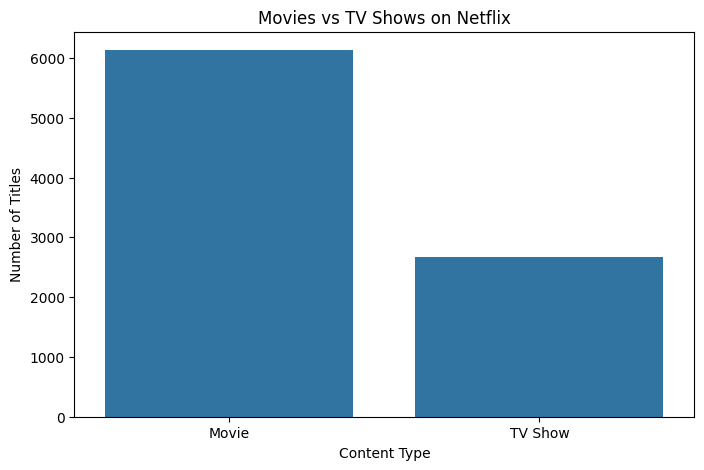

In [11]:
# Movies vs TV Shows - Visualization

type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.index, y=type_counts.values)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [12]:
# Percentage distribution

type_percentage = (df["type"].value_counts(normalize=True) * 100).round(2)

type_percentage

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

### Key Insight

- Netflix has **6,131 Movies** and **2,676 TV Shows** in the dataset.
- Movies account for approximately **69.62%** of the catalog.
- TV Shows account for approximately **30.38%** of the catalog.
- Therefore, the Netflix catalog contains more than twice as many Movies as TV Shows.

# EDA 2 — Content Added Over Time

In [13]:
df["year_added"].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

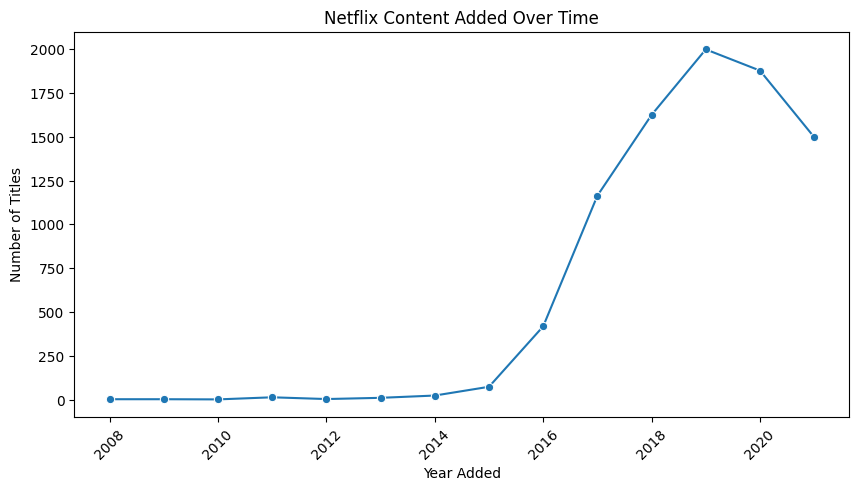

In [14]:
# Content added to Netflix over the years

yearly_content = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_content.index, y=yearly_content.values, marker="o")

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [15]:
# Year with the highest number of additions

peak_year = yearly_content.idxmax()
peak_count = yearly_content.max()

print("Peak Year:", int(peak_year))
print("Titles Added:", peak_count)

Peak Year: 2019
Titles Added: 1999


### Key Insight

- Netflix added relatively little content before **2016**, indicating slower catalog expansion in the earlier years.
- Content additions increased sharply from **2016 to 2019**, showing a period of rapid catalog growth.
- **2019 was the peak year**, with **1,999 titles** added to the dataset.
- After 2019, the number of additions declined, with **1,878 titles in 2020** and **1,498 titles in 2021**.
- Overall, the data shows that Netflix's catalog expansion **accelerated significantly during the late 2010s**, followed by a decline in additions after 2019.

# EDA 3 — Top Genres

## Objective

Analyze the most common genres available on Netflix.

In [16]:
genre_counts = genre_df["genre"].value_counts()

genre_counts

genre
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows                 

In [17]:
genre_counts.head(15)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

In [18]:
genre_counts = genre_df["genre"].value_counts()

genre_counts

genre
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows                 

In [19]:
top_10_genres=genre_counts.head(10)

In [20]:
top_10_genres

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

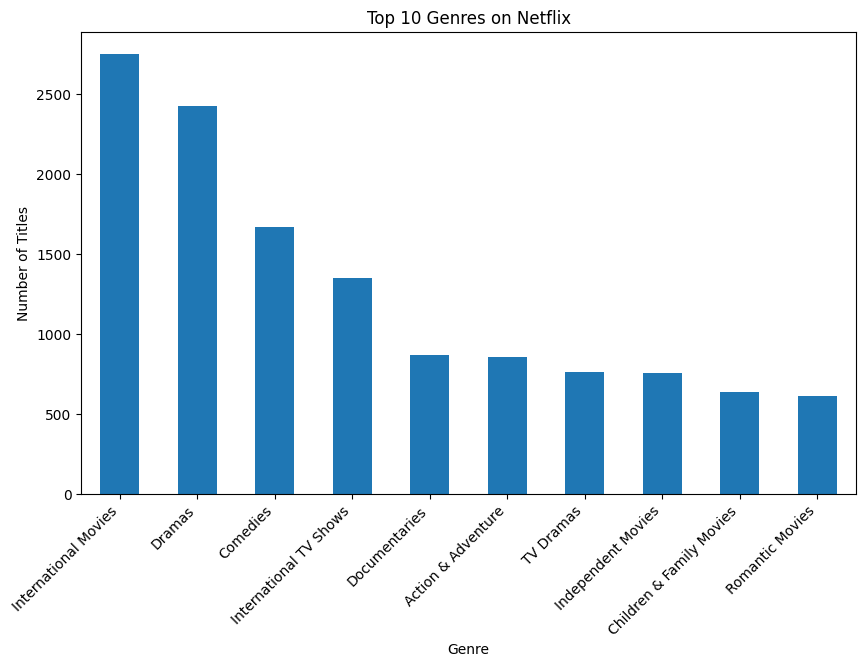

In [22]:
# Top 10 Genres - Bar Chart

plt.figure(figsize=(10, 6))

top_10_genres.plot(kind="bar")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

plt.show()

## Key Insights

- **International Movies** are the most common genre on Netflix, with **2,752 titles**.
- **Dramas** are the second most common genre, with **2,427 titles**.
- **Comedies** rank third, with **1,674 titles**.
- **International TV Shows** are the most represented TV-related genre, with **1,351 titles**.
- **Documentaries** and **Action & Adventure** also have a significant presence, with **869** and **859 titles** respectively.
- Overall, Netflix's catalog shows a strong preference for **international content, drama, and comedy**.

# EDA 4 — Content by Country

## Objective

Analyze the countries that contribute the most content to Netflix.

In [23]:
# Create country table

country_df = df[["show_id", "country"]].copy()

country_df["country"] = country_df["country"].str.split(",")

country_df = country_df.explode("country")

country_df["country"] = country_df["country"].str.strip()

In [24]:
country_counts = country_df["country"].value_counts()

country_counts.head(15)

country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Name: count, dtype: int64

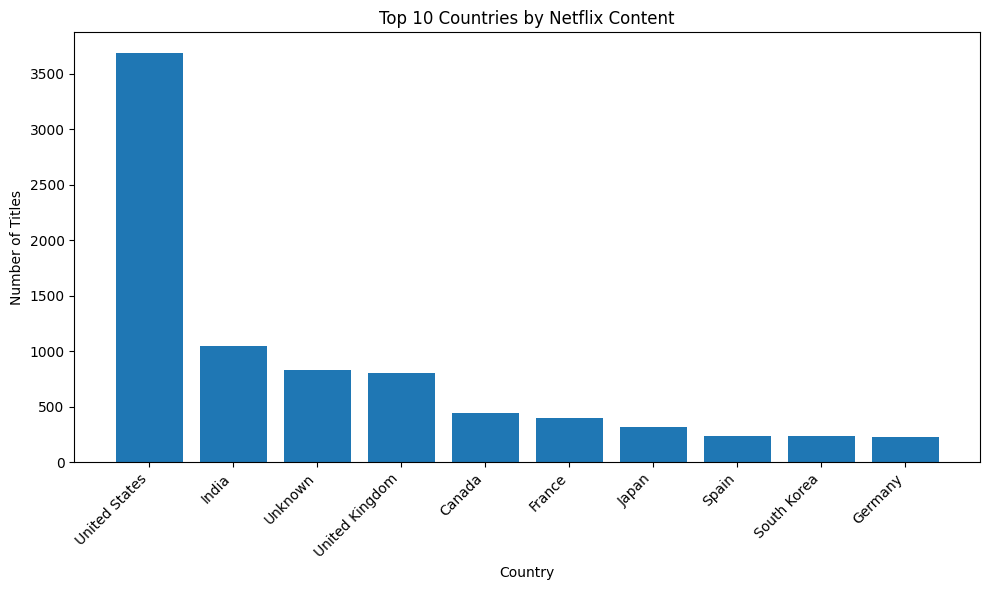

In [25]:
# Top 10 countries

top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Key Insights

- The **United States** contributes the most content to Netflix, with **3,690 titles**.
- **India** ranks second with **1,046 titles**, followed by the **United Kingdom** with **806 titles**.
- The United States has a significantly larger content contribution than other countries.
- **Canada, France, and Japan** also have a notable presence in the Netflix catalog.
- The distribution shows that Netflix has a strong content base from **North America, Europe, and Asia**.
- The high number of **Unknown** country entries (**831**) indicates that some titles have missing country information in the dataset.

# EDA 5 — Ratings Distribution

## Objective

Analyze the distribution of content across different audience ratings on Netflix.

In [26]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

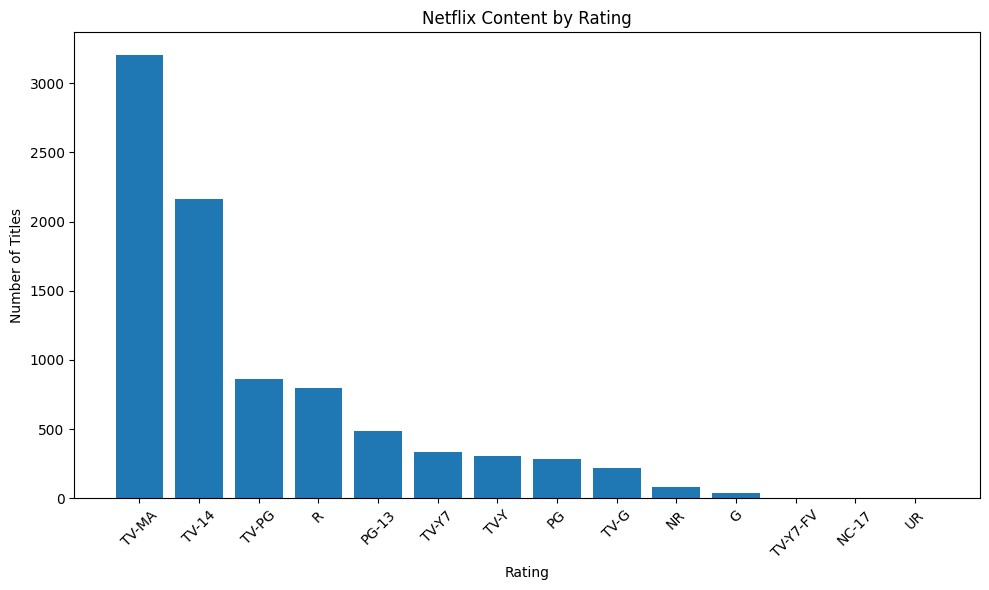

In [27]:
# Remove Unknown ratings for visualization

rating_chart = rating_counts[rating_counts.index != "Unknown"]

plt.figure(figsize=(10, 6))

plt.bar(rating_chart.index, rating_chart.values)

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insights – EDA 5: Content by Rating

- TV-MA is the most common rating on Netflix, with 3,207 titles.
- TV-14 is the second most common rating, with 2,160 titles.
- TV-PG and R-rated content are also significant categories.
- The majority of Netflix content is targeted toward mature or teenage audiences.
- G-rated and other less common ratings represent a very small portion of the catalog.

In [28]:
df[["type", "duration"]].head(10)

,type,duration
0,Movie,90 min
1,TV Show,2 Seasons
2,TV Show,1 Season
3,TV Show,1 Season
4,TV Show,2 Seasons
5,TV Show,1 Season
6,Movie,91 min
7,Movie,125 min
8,TV Show,9 Seasons
9,Movie,104 min


In [29]:
movie_duration = df[df["type"] == "Movie"].copy()

movie_duration["duration_min"] = (
    movie_duration["duration"]
    .str.extract("(\d+)")
    .astype(float)
)

movie_duration[["title", "duration", "duration_min"]].head()

,title,duration,duration_min
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0


In [30]:
movie_duration["duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

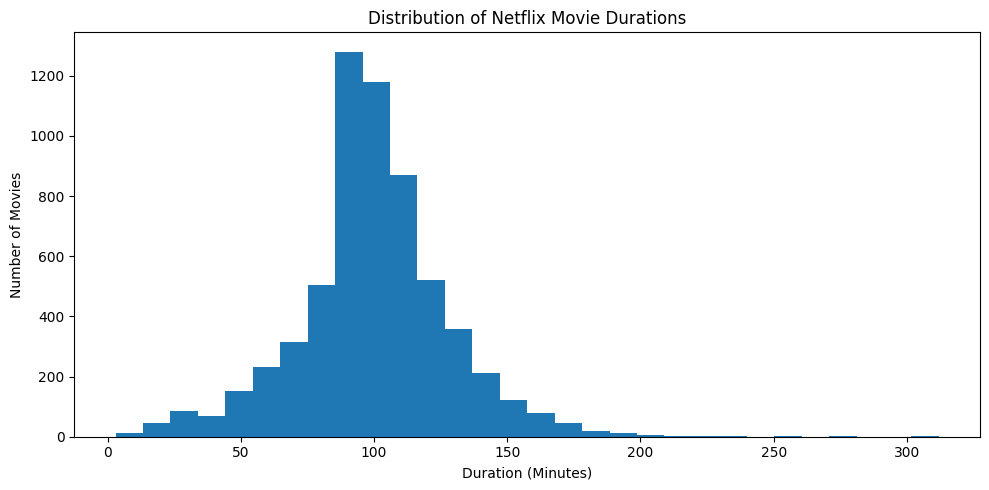

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(movie_duration["duration_min"], bins=30)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

### Key Insights – EDA 6: Movie Duration

- Netflix has 6,131 movies in the dataset.
- The average movie duration is approximately **100 minutes**.
- The median duration is **98 minutes**, showing that a typical Netflix movie is around 1.5–2 hours long.
- Most movies are concentrated between approximately **80 and 120 minutes**.
- Very short and extremely long movies are relatively uncommon.
- The distribution is slightly right-skewed because a smaller number of movies have durations above 150 minutes.

In [33]:
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(15)

release_year
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

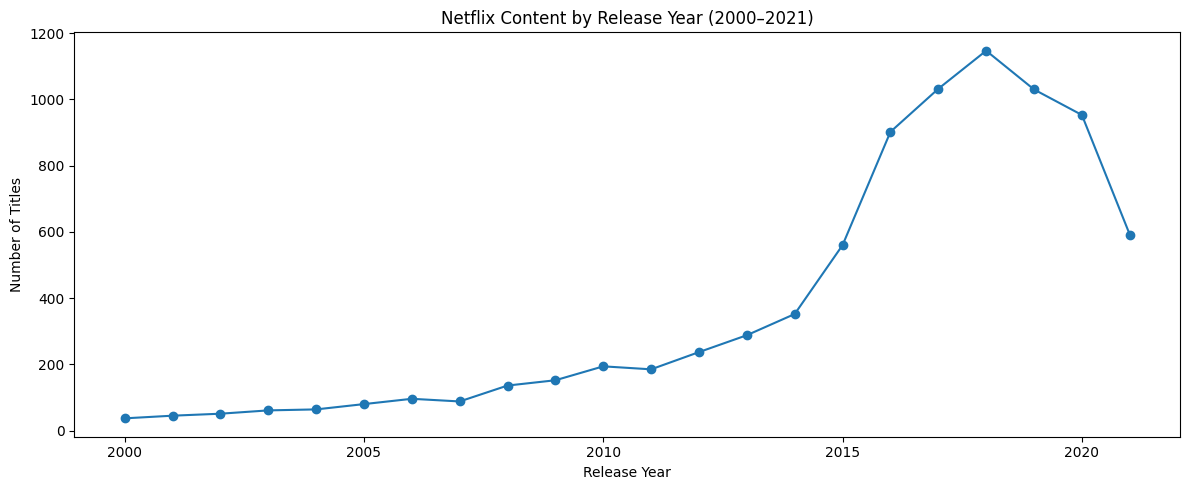

In [35]:
recent_years = df[df["release_year"] >= 2000]

year_counts = recent_years["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

plt.title("Netflix Content by Release Year (2000–2021)")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

### Key Insights – EDA 7: Content by Release Year

- Netflix content shows a strong upward trend in release years after 2010.
- The number of titles increased rapidly between 2015 and 2018.
- **2018 has the highest number of titles**, with around 1,147 titles.
- Content from 2016–2020 makes up a large portion of the dataset.
- The decline after 2019 should not be interpreted as an actual decline in Netflix production because the dataset ends in 2021 and recent releases may be underrepresented.

> **Note:** `release_year` represents the original release year of the movie or TV show, not the year it was added to Netflix.